
## Notebook 2: Unsupervised Classification — Gaussian Mixture Model

This notebook is adapted from *Week 4 Unsupervised Learning* from the GEOL0069 Jupyter Notebook.

GMM is applied to the NDWI, MNDWI and NDVI index stacks exported from Notebook 1 to classify
the Aral Sea basin into four land cover types: open water, brine/shallow water, salt flat,
and desert scrub. The same trained model is applied across all four years (2015, 2018, 2021, 2024)
to produce a water area time series showing how the lake has changed over time.



## Setup
Run this cell first. It imports all required libraries, mounts Google Drive,
and starts the timer used to calculate the environmental cost at the end of
the notebook.

In [ ]:
import time #timer for environmental cost
notebook_start = time.time()


import rasterio
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pickle
import os

from google.colab import drive
drive.mount('/content/drive')

# Paths
DATA_DIR = '/content/drive/MyDrive/aral_sea/'
FIG_DIR  = '/content/drive/MyDrive/aral_sea/figures/'
os.makedirs(FIG_DIR, exist_ok=True)

YEARS = [2015, 2018, 2021, 2024]
PIXEL_AREA_KM2 = 0.01  # 100m x 100m = 0.01 km²

Mounted at /content/drive


## Load Index Data

This cell loads the GeoTIFF files exported from Notebook 1 into numpy arrays for classification.
One file is loaded per year, giving us the NDWI, MNDWI and NDVI values for every pixel
in the Aral Sea region.

In [ ]:
# Adapted from Week 4 skeleton rasterio loading pattern
data = {}

for year in YEARS:
    path = f'{DATA_DIR}aral_sea_indices_{year}.tif'

    with rasterio.open(path) as src:
        ndwi  = src.read(1).astype(float)  # band 1 = NDWI
        mndwi = src.read(2).astype(float)  # band 2 = MNDWI
        ndvi  = src.read(3).astype(float)  # band 3 = NDVI


    for arr in [ndwi, mndwi, ndvi]:
        arr[arr < -1] = np.nan

    data[year] = {'ndwi': ndwi, 'mndwi': mndwi, 'ndvi': ndvi}
    print(f'{year}: loaded — shape {ndwi.shape}')

H, W = data[2015]['ndwi'].shape

2015: loaded — shape (784, 892)
2018: loaded — shape (784, 892)
2021: loaded — shape (784, 892)
2024: loaded — shape (784, 892)


## Prepare Features

The three index arrays are stacked into a single feature matrix, matching the format used
in the Week 4 notebook where band data is stacked and reshaped before clustering.
Invalid pixels (cloud masked areas) are removed before fitting.

In [ ]:
# Kept from Week 4 skeleton — stack bands and create valid data mask
ndwi_2015  = data[2015]['ndwi']
mndwi_2015 = data[2015]['mndwi']
ndvi_2015  = data[2015]['ndvi']

# Stack features — shape (H*W, 3)
band_stack = np.dstack([ndwi_2015, mndwi_2015, ndvi_2015])
valid_data_mask = np.all(~np.isnan(band_stack), axis=2)

# Reshape for GMM — only including valid data
# Kept from Week 4 skeleton pattern
X = band_stack[valid_data_mask].reshape((-1, 3))

print(f'Valid pixels for training: {X.shape[0]}')

# Scale features — kept from Week 4 skeleton
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Valid pixels for training: 193779


## GMM Classification

GMM is used instead of K-means because it provides soft probabilistic class assignments
rather than hard boundaries — more appropriate for the gradual transitions between land
cover types in the Aral Sea basin (e.g. shallow brine grading into salt flat).

The model is fitted on 2015 data only and then applied to all years. This ensures
cluster definitions stay fixed across time so pixel count changes reflect real
land cover change rather than model drift.

In [ ]:
# Adapted from Week 4 skeleton GMM implementation
# CHANGED: n_components=4 (four Aral Sea land cover types)
# instead of n_components=2 (sea ice / lead)

gmm = GaussianMixture(n_components=4, random_state=0)
gmm.fit(X_scaled)
labels_2015 = gmm.predict(X_scaled)

# Check how many pixels are in each cluster
unique, counts = np.unique(labels_2015, return_counts=True)
class_counts = dict(zip(unique, counts))
print('Cluster counts (2015):', class_counts)

Cluster counts (2015): {np.int64(0): np.int64(85381), np.int64(1): np.int64(12641), np.int64(2): np.int64(12353), np.int64(3): np.int64(83404)}


## Assign Semantic Labels

GMM assigns arbitrary cluster numbers with no inherent meaning. This cell
inspects the mean index values of each cluster to identify which cluster
corresponds to which land cover type. Clusters are sorted by their mean
NDWI value — the highest NDWI indicates open water, decreasing through
brine, salt flat, and desert scrub. This step is specific to this project
and is not in the Week 4 skeleton, which works with pre-known classes.

In [ ]:
# Inspect cluster means to assign land cover labels
means_original = scaler.inverse_transform(gmm.means_)
print('Cluster means (NDWI, MNDWI, NDVI):')
for i, m in enumerate(means_original):
    print(f'  Cluster {i}: NDWI={m[0]:.3f}  MNDWI={m[1]:.3f}  NDVI={m[2]:.3f}')

# Sort clusters by NDWI — highest = open water
ndwi_means = means_original[:, 0]
sorted_clusters = np.argsort(ndwi_means)[::-1]

CLASS_NAMES   = ['Open water', 'Brine / shallow', 'Salt flat', 'Desert scrub']
CLASS_COLOURS = ['#1a6faf', '#7ec8e3', '#f5deb3', '#c8a882']

# Map original cluster id to semantic label
cluster_to_class = {int(sorted_clusters[i]): i for i in range(4)}
print('\nCluster to class mapping:')
for orig, cls in cluster_to_class.items():
    print(f'  Cluster {orig} → {CLASS_NAMES[cls]}')

Cluster means (NDWI, MNDWI, NDVI):
  Cluster 0: NDWI=-0.213  MNDWI=-0.309  NDVI=0.111
  Cluster 1: NDWI=0.847  MNDWI=0.874  NDVI=-0.606
  Cluster 2: NDWI=-0.115  MNDWI=0.107  NDVI=0.106
  Cluster 3: NDWI=-0.208  MNDWI=-0.312  NDVI=0.096

Cluster to class mapping:
  Cluster 1 → Open water
  Cluster 2 → Brine / shallow
  Cluster 3 → Salt flat
  Cluster 0 → Desert scrub


## Apply GMM to All Years

The fitted GMM model is applied to each year's index stack using the same
stacking and masking pattern from the Week 4 skeleton. Applying the same
model across all years — rather than refitting each time — ensures that
cluster definitions stay fixed so pixel count changes reflect genuine
land cover change rather than model variation.

In [ ]:
label_maps = {}

for year in YEARS:
    ndwi  = data[year]['ndwi']
    mndwi = data[year]['mndwi']
    ndvi  = data[year]['ndvi']

    # Stack and mask — kept from Week 4 skeleton pattern
    band_stack_yr = np.dstack([ndwi, mndwi, ndvi])
    valid_mask_yr = np.all(~np.isnan(band_stack_yr), axis=2)
    X_yr = band_stack_yr[valid_mask_yr].reshape((-1, 3))
    X_yr_scaled = scaler.transform(X_yr)

    # Predict using the 2015-fitted model
    labels_yr = gmm.predict(X_yr_scaled)

    # Reconstruct full image label map
    label_map = np.full(H * W, np.nan)
    label_map[valid_mask_yr.ravel()] = labels_yr
    label_maps[year] = label_map.reshape(H, W)

    print(f'{year}: classified')

2015: classified
2018: classified
2021: classified
2024: classified


## Plot Classification Maps

Classification maps for all four years are plotted side by side to show how
the land cover has changed across the study period.

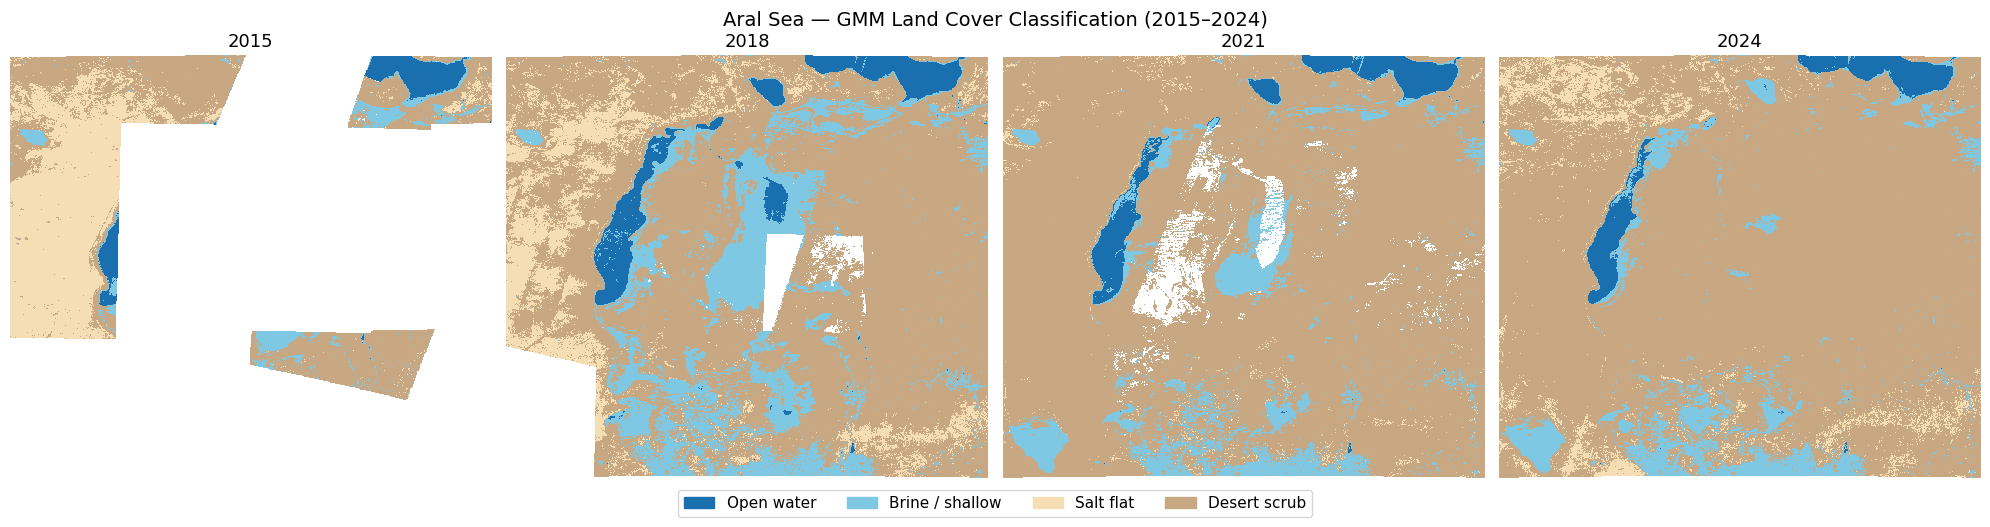

In [ ]:
# Kept from Week 4 skeleton plotting pattern
cmap   = mcolors.ListedColormap(CLASS_COLOURS)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, len(YEARS), figsize=(5 * len(YEARS), 5))

for ax, year in zip(axes, YEARS):
    remapped = np.vectorize(
        lambda x: cluster_to_class.get(int(x), np.nan) if not np.isnan(x) else np.nan
    )(label_maps[year])

    ax.imshow(remapped, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(str(year), fontsize=13)
    ax.axis('off')

patches = [mpatches.Patch(color=c, label=n)
           for c, n in zip(CLASS_COLOURS, CLASS_NAMES)]
fig.legend(handles=patches, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.05), fontsize=11)

plt.suptitle('Aral Sea — GMM Land Cover Classification (2015–2024)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}gmm_classification_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## Water Area Time Series

Pixels are counted per land cover class for each year and converted to km².
This produces the headline result — how much open water has been lost
between 2015 and 2024

Class                2015  2018  2021  2024
------------------------------------------------------------
Open water                126 km²       317 km²       244 km²       212 km²
Brine / shallow           124 km²      1066 km²       613 km²       547 km²
Salt flat                 834 km²       672 km²        63 km²       382 km²
Desert scrub              854 km²      4405 km²      5781 km²      5818 km²


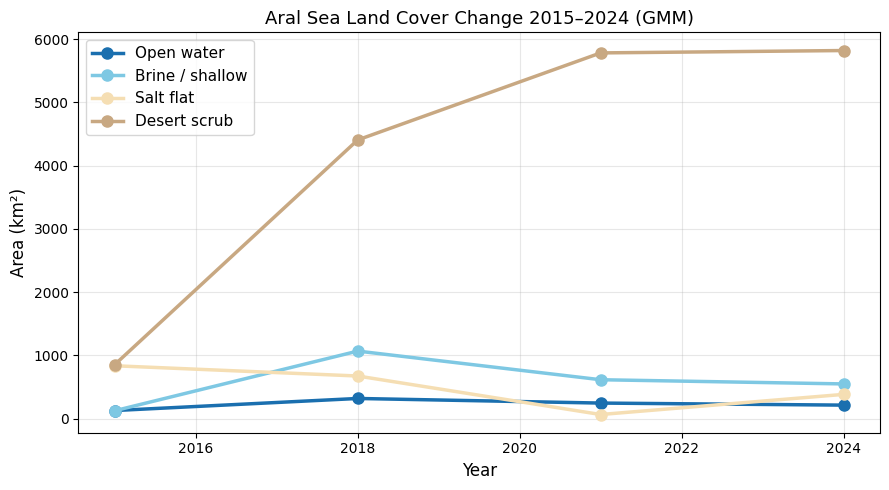


Open water area lost 2015 to 2024: -85 km²


In [ ]:
results = {name: [] for name in CLASS_NAMES}

for year in YEARS:
    remapped = np.vectorize(
        lambda x: cluster_to_class.get(int(x), -1) if not np.isnan(x) else -1
    )(label_maps[year])

    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        count    = np.sum(remapped == cls_idx)
        area_km2 = count * PIXEL_AREA_KM2
        results[cls_name].append(area_km2)

# Print summary table
print(f'{"Class":<20}', '  '.join(str(y) for y in YEARS))
print('-' * 60)
for cls_name in CLASS_NAMES:
    vals = '  '.join(f'{v:>8.0f} km²' for v in results[cls_name])
    print(f'{cls_name:<20} {vals}')

# Time series plot
fig, ax = plt.subplots(figsize=(9, 5))
for cls_name, colour in zip(CLASS_NAMES, CLASS_COLOURS):
    ax.plot(YEARS, results[cls_name], 'o-', color=colour,
            linewidth=2.5, markersize=8, label=cls_name)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Area (km²)', fontsize=12)
ax.set_title('Aral Sea Land Cover Change 2015–2024 (GMM)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}water_area_timeseries.png', dpi=150)
plt.show()

water_loss = results['Open water'][0] - results['Open water'][-1]
print(f'\nOpen water area lost 2015 to 2024: {water_loss:.0f} km²')

## Save GMM Outputs

The GMM classification maps are saved to Google Drive so they can be
loaded in Notebook 3 for the side by side visual comparison with the
CNN results.

In [ ]:
# Save GMM label maps for visual comparison in Notebook 3
import pickle

with open(f'{DATA_DIR}gmm_outputs.pkl', 'wb') as f:
    pickle.dump({
        'label_maps': label_maps,
        'cluster_to_class': cluster_to_class
    }, f)

print('GMM outputs saved for Notebook 3 comparison')

GMM outputs saved for Notebook 3 comparison


## Environmental Cost

Runtime is recorded automatically and used to estimate energy consumption,
assuming a 20W CPU, UK grid carbon intensity of 0.233 kg CO2/kWh,
and an electricity cost of £0.30/kWh.

In [ ]:
runtime_mins = (time.time() - notebook_start) / 60
energy_kwh   = 0.020 * (runtime_mins / 60)
co2_kg       = energy_kwh * 0.233
cost_gbp     = energy_kwh * 0.30

print('=== Notebook 2 Environmental Cost ===')
print(f'Runtime:  {runtime_mins:.2f} min')
print(f'Energy:   {energy_kwh * 1000:.4f} Wh')
print(f'CO2e:     {co2_kg * 1000:.4f} g')
print(f'Cost:     £{cost_gbp:.4f}')

=== Notebook 2 Environmental Cost ===
Runtime:  0.77 min
Energy:   0.2560 Wh
CO2e:     0.0597 g
Cost:     £0.0001
